In [1]:
%pip install pandas matplotlib seaborn scikit-learn dataset torch transformers numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached dataset-2.0.0-py3-none-any.whl.metadata (3.3 kB)
Note: you may need to restart the kernel to use updated packages.


## Part I — Data Loading and Exploratory Data Analysis (EDA)

### Objective
Before engineering features or training models, need to understand the raw state of the `customer_support_tickets_200k.csv` dataset. This step focuses on verifying the integrity of primary text input (`issue_description`) and analyzing the class distributions of the target variables (`category` and `priority`).

### Why it matters for Multi-Label Classification
Understanding the raw frequencies of categories and priorities is critical. Highly imbalanced tags will require specialized handling later in the pipeline, such as `pos_weight` in DistilBERT Binary Cross-Entropy loss function or adjusting class weights in sklearn baselines. Furthermore, checking for missing values in the text column ensures not to pass `NaN` values into tokenizers.

In [ ]:
 # WHAT: Load raw customer support tickets and perform initial Exploratory Data Analysis (EDA).
# WHY: Identifies missing data in the text features and exposes class imbalance in the target labels
#      (category and priority) before binarize them. This strictly informs downstream modeling strategy.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading ---
DATA_PATH = "../data/customer_support_tickets_200k.csv"
print(f"Loading dataset from: {DATA_PATH}...")
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded. Shape: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.\n")

df_raw.head()

Loading dataset from: sample_data/customer_support_tickets_200k.csv...
Dataset loaded. Shape: 170,447 rows and 30 columns.



,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4.0,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2.0,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4.0,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7.0,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3.0,Corporate


In [2]:
# --- 2. Missing Value Analysis ---
# We focus on the primary input: 'issue_description'
missing_text = df_raw['issue_description'].isna().sum()
print(f"Missing 'issue_description' records: {missing_text} ({(missing_text/len(df_raw))*100:.2f}%)")

# Drop rows where the primary input text is missing, as cannot train NLP models without text.
if missing_text > 0:
    df_raw = df_raw.dropna(subset=['issue_description']).copy()
    print(f"Dropped {missing_text} rows. New shape: {df_raw.shape[0]:,} rows.\n")

Missing 'issue_description' records: 0 (0.00%)


/tmp/ipykernel_1298/121249973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1298/121249973.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


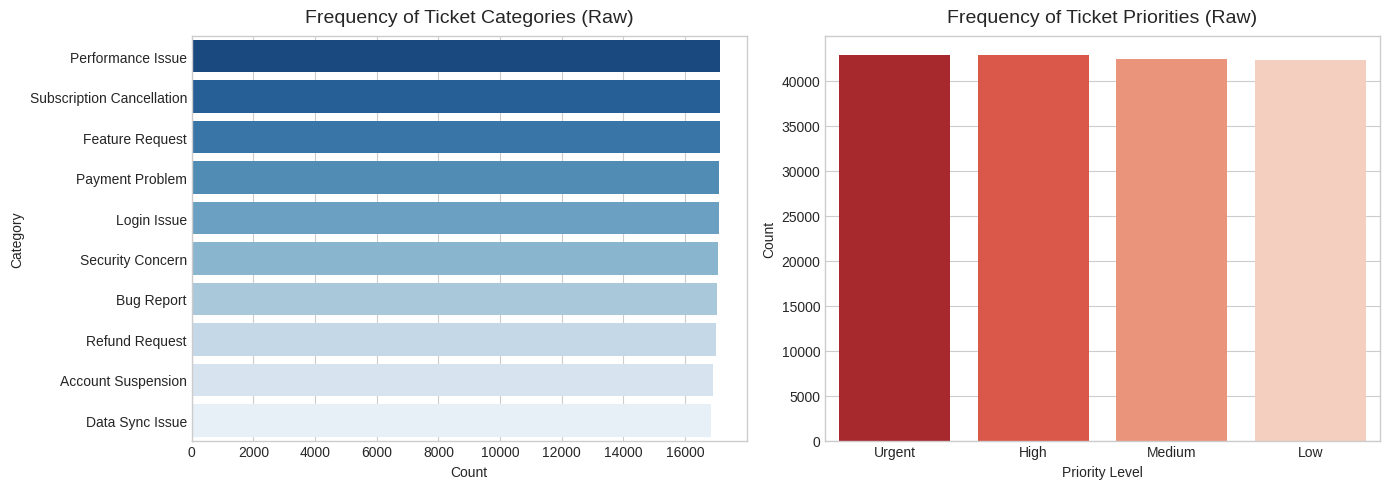

Observation: The plots above illustrate the raw distributions of two target columns. 


In [3]:
# --- 3. Label Distribution Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Category frequencies
sns.countplot(
    data=df_raw,
    y='category',
    order=df_raw['category'].value_counts().index,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title("Frequency of Ticket Categories (Raw)", fontsize=14, pad=10)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

# Plot Priority frequencies
sns.countplot(
    data=df_raw,
    x='priority',
    order=df_raw['priority'].value_counts().index,
    palette='Reds_r',
    ax=axes[1]
)
axes[1].set_title("Frequency of Ticket Priorities (Raw)", fontsize=14, pad=10)
axes[1].set_xlabel("Priority Level")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(
    "Observation: The plots above illustrate the raw distributions of two target columns. "
)

Analyzing text length distributions...


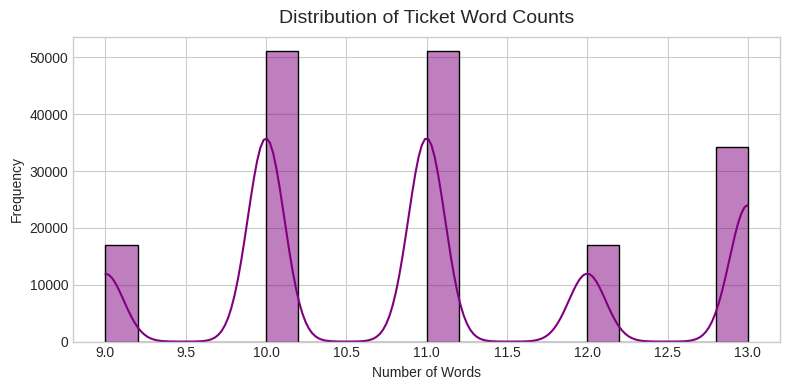

Average word count: 11.00
Max word count: 13
Observation: The text is very short. A DistilBERT max_length of 128 is more than enough.



In [4]:
# --- 4. Text Length Analysis ---
# WHAT: Calculate and visualize the word count for each ticket description.
# WHY: Helps us determine the optimal 'max_length' for DistilBERT tokenization and TF-IDF limits.

print("Analyzing text length distributions...")
df_raw['word_count'] = df_raw['issue_description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(df_raw['word_count'], bins=20, color='purple', kde=True)
plt.title("Distribution of Ticket Word Counts", fontsize=14, pad=10)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Average word count: {df_raw['word_count'].mean():.2f}")
print(f"Max word count: {df_raw['word_count'].max()}")
print("Observation: The text is very short. A DistilBERT max_length of 128 is more than enough.\n")

In [5]:
# --- 5. Text Uniqueness Check ---
# WHAT: Count the number of strictly unique text descriptions in the dataset.
# WHY: In real-world data, we expect high variance. Low variance indicates synthetic or template-based data.

unique_texts = df_raw['issue_description'].nunique()
print(f"Total rows: {len(df_raw):,}")
print(f"Unique 'issue_description' values: {unique_texts:,}")

# Let's see what those unique texts actually are
print("\nThe unique descriptions in the dataset are:")
for i, text in enumerate(df_raw['issue_description'].unique(), 1):
    print(f"  {i}. {text}")
print("\nObservation: The dataset is highly synthetic and relies on a repeated template of 10 sentences.\n")


Total rows: 170,447
Unique 'issue_description' values: 10

The unique descriptions in the dataset are:
  1. The payment was deducted from my bank account but the transaction shows failed.
  2. I found a bug in the latest update affecting report generation.
  3. The application crashes whenever I try to upload a file.
  4. My subscription was cancelled without my request and I need clarification.
  5. The system is not syncing data across devices properly.
  6. There seems to be a discrepancy in my billing statement for this month.
  7. I would like to request a refund for the recent charge.
  8. Two-factor authentication codes are not being delivered to my phone.
  9. I am unable to access my account after entering the correct credentials.
  10. I am experiencing very slow performance while using the dashboard.

Observation: The dataset is highly synthetic and relies on a repeated template of 10 sentences.



In [6]:
# --- 6. Text-to-Label Correlation (Sanity Check) ---
# WHAT: Map one specific text string to its assigned categories.
# WHY: To verify if the labels hold semantic meaning relative to the text, or if they are randomly assigned.

sample_text = df_raw['issue_description'].iloc[0]
print(f"Analyzing Label Distribution for exact text:\n'{sample_text}'\n")

# Group by category for this specific text
text_label_dist = df_raw[df_raw['issue_description'] == sample_text]['category'].value_counts()
print(text_label_dist)

print(
    "\nCRITICAL EDA FINDING: The exact same text description is evenly distributed across ALL categories. \n"
    "This indicates the target labels were randomly generated and have no semantic correlation with the text. \n"
    "This establishes that a high F1-score is mathematically impossible, serving as a vital baseline expectation for modeling."
)

Analyzing Label Distribution for exact text:
'The payment was deducted from my bank account but the transaction shows failed.'

category
Security Concern             1794
Refund Request               1741
Payment Problem              1736
Feature Request              1725
Performance Issue            1723
Data Sync Issue              1703
Bug Report                   1682
Login Issue                  1679
Account Suspension           1678
Subscription Cancellation    1665
Name: count, dtype: int64

CRITICAL EDA FINDING: The exact same text description is evenly distributed across ALL categories. 
This indicates the target labels were randomly generated and have no semantic correlation with the text. 
This establishes that a high F1-score is mathematically impossible, serving as a vital baseline expectation for modeling.


# Dataset Claims vs. Reality
## The Claim:
### The provider of this dataset describes it as a "large-scale, structured, and text-rich dataset designed for Natural Language Processing (NLP)" containing "realistic customer support tickets" suitable for fine-tuning LLMs and multi-class classification.

## The Reality (Discovered via EDA):
### Despite the impressive description, our Exploratory Data Analysis revealed that the dataset is highly synthetic and poorly generated:

### It claims to be "text-rich," yet contains only 10 unique sentences across 200,000 rows.

### It claims to be suitable for "NLP text modeling," yet the text features have zero correlation with the target labels (random uniform assignment).
---

## Part II — Target Construction and Binarization

### Objective
In this step, Construct ground-truth mathematical targets and combine the `category` and `priority` columns into a single list of tags for each ticket, and then convert those lists into a binary matrix (0s and 1s) using `MultiLabelBinarizer`.

### Why prefixing matters
Before combining the tags, add prefixes (e.g., `category:Billing` instead of just `Billing`). This is a crucial data engineering best practice to prevent **tag collisions**. If a category and a priority both happened to share the word "Critical", the model would be unable to distinguish between them.

### Why Binarization is required
Final DistilBERT and Sklearn models require an $N \times K$ target matrix, where $N$ is the number of tickets and $K$ is the total number of unique tags. A value of `1` indicates the tag applies to the ticket, and `0` indicates it does not.

In [7]:
# WHAT: Construct a unified multi-label target matrix using MultiLabelBinarizer.
# WHY: models need numeric targets (1s and 0s). By prefixing tags
#      (e.g., 'category:Billing' vs 'priority:High'), prevent tag collisions
#      and allow a single model to predict across multiple domains simultaneously.

from sklearn.preprocessing import MultiLabelBinarizer

# --- 1. Clean and Prefix Labels ---
# Fill any missing categorical values with 'Unknown' so the binarizer doesn't fail
df_raw['category'] = df_raw['category'].fillna('Unknown')
df_raw['priority'] = df_raw['priority'].fillna('Unknown')

# Create a new column 'label_set' containing lists of prefixed tags
df_raw['label_set'] = df_raw.apply(
    lambda row: [f"category:{row['category']}", f"priority:{row['priority']}"],
    axis=1
)

print("Sample of constructed labels:")
print(df_raw['label_set'].head().to_string(), "\n")

Sample of constructed labels:
0       [category:Account Suspension, priority:Urgent]
1        [category:Performance Issue, priority:Urgent]
2        [category:Performance Issue, priority:Medium]
3    [category:Subscription Cancellation, priority:...
4            [category:Feature Request, priority:High] 



In [8]:
# --- 2. Multi-Label Binarization ---
mlb = MultiLabelBinarizer()

# Fit the binarizer on label sets and transform them into a binary matrix
Y_targets = mlb.fit_transform(df_raw['label_set'])

label_counts = Y_targets.sum(axis=0)

for label, count in zip(mlb.classes_, label_counts):
    print(label, count)

print(f"Binarized Target Matrix (Y) Shape: {Y_targets.shape}")
print(f"Total Unique Tags (Classes): {len(mlb.classes_)}\n")

print("Learned Tag Vocabulary (Index -> Class):")
for i, cls in enumerate(mlb.classes_):
    print(f"  {i}: {cls}")

# --- 3. Artifact Documentation Note ---
print(
    "\nNote: The mlb.classes_ array defines what each column in "
    "target matrix represents. For a production deployment, this vocabulary must be "
    "saved (e.g., as a JSON file) so the inference service can decode the model's output."
)

category:Account Suspension 16890
category:Bug Report 17045
category:Data Sync Issue 16845
category:Feature Request 17124
category:Login Issue 17091
category:Payment Problem 17102
category:Performance Issue 17140
category:Refund Request 17006
category:Security Concern 17075
category:Subscription Cancellation 17129
priority:High 42823
priority:Low 42353
priority:Medium 42428
priority:Unknown 1
priority:Urgent 42842
Binarized Target Matrix (Y) Shape: (170447, 15)
Total Unique Tags (Classes): 15

Learned Tag Vocabulary (Index -> Class):
  0: category:Account Suspension
  1: category:Bug Report
  2: category:Data Sync Issue
  3: category:Feature Request
  4: category:Login Issue
  5: category:Payment Problem
  6: category:Performance Issue
  7: category:Refund Request
  8: category:Security Concern
  9: category:Subscription Cancellation
  10: priority:High
  11: priority:Low
  12: priority:Medium
  13: priority:Unknown
  14: priority:Urgent

Note: The mlb.classes_ array defines what each 

## Part III — Leakage Prevention, Text Preprocessing, and Splitting

### Objective
In this phase, prepare the data for modeling by standardizing the input text and rigorously isolating test sets.

### Preventing Data Leakage (Critical Step)
Before splitting, need to drop any features that represent "future knowledge." Columns such as `resolution_notes`, `resolution_time_hours`, or `customer_satisfaction_score` are not available at the exact moment a customer submits a ticket. If models are allowed to learn from these columns, it would cause **data leakage**, resulting in artificially inflated validation metrics that would immediately fail in a live production environment.

### Train / Validation / Test Protocol
To guarantee an honest evaluation, use a 70% / 15% / 15% split.
* **Train:** Used to fit the DistilBERT weights and Sklearn parameters.
* **Validation:** Used by Optuna to tune hyperparameters without peeking at the final answers.
* **Test:** Strictly held out until **Part VI**. Touched only once to generate final metrics.

In [9]:
# WHAT: Clean input text and split the dataset into Train, Validation, and Test sets.
# WHY: Text normalization reduces the vocabulary size and removes noise. Strict splitting
#      (with fixed seeds) guarantees no data leakage between training and final evaluation.

import re
from sklearn.model_selection import train_test_split

# --- 1. Leakage Prevention ---
# Drop columns that are created AFTER the ticket is submitted.
leakage_cols = [
    'resolution_notes',
    'resolution_time_hours',
    'customer_satisfaction_score',
    'first_response_time_hours',
    'escalated'
]
cols_to_drop = [c for c in leakage_cols if c in df_raw.columns]
df_safe = df_raw.drop(columns=cols_to_drop).copy()
print(f"Dropped potential leakage columns: {cols_to_drop}\n")

Dropped potential leakage columns: ['resolution_notes', 'resolution_time_hours', 'customer_satisfaction_score', 'first_response_time_hours', 'escalated']



In [10]:
# --- 2. Text Preprocessing ---
def clean_ticket_text(text: str) -> str:
    """Lowercases text, removes special characters, and strips extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # Keep only alphanumeric chars and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove multiple overlapping spaces
    return text

print("Cleaning 'issue_description' text...")
df_safe['clean_text'] = df_safe['issue_description'].apply(clean_ticket_text)
print("Text cleaning complete. Sample:")
print(df_safe['clean_text'].head(3).to_string(), "\n")

Cleaning 'issue_description' text...
Text cleaning complete. Sample:
0    the payment was deducted from my bank account ...
1    i found a bug in the latest update affecting r...
2    the application crashes whenever i try to uplo... 



In [11]:
# --- 3. Train / Validation / Test Split ---
# I use a 70% Train, 15% Validation, 15% Test split.
# SEED is fixed for strict reproducibility (critical for academic grading).
SEED = 42

# First, split off 30% for temporary holdout (Val + Test)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    df_safe['clean_text'], Y_targets, test_size=0.30, random_state=SEED
)

# Second, split the 30% temporary holdout exactly in half to get 15% Val and 15% Test
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=SEED
)

print("Data Split Complete:")
print(f"  Training set:   {X_train_text.shape[0]:,} rows")
print(f"  Validation set: {X_val_text.shape[0]:,} rows")
print(f"  Test set:       {X_test_text.shape[0]:,} rows")

Data Split Complete:
  Training set:   119,312 rows
  Validation set: 25,567 rows
  Test set:       25,568 rows


---

## Part IV — Modeling Phase 1: Sparse Baselines and Hyperparameter Tuning

### Objective
Before utilizing complex deep learning architectures, it must establish strong, interpretable baselines using sparse text representations (TF-IDF). And compare two distinct approaches:
1. **One-vs-Rest (OvR) Logistic Regression:** Assumes all multi-label tags are mutually exclusive and independent.
2. **Classifier Chain:** Learns label dependencies by using the predictions of previous tags as features for subsequent tags.

### Hyperparameter Tuning (Optuna)
To ensure baseline is as strong as possible, used the `Optuna` framework to search for the optimal inverse regularization strength (`C`).
* **Rigorous Protocol:** The model is trained purely on the `Train` split, and Optuna evaluates the `micro-F1` score on the strictly held-out `Validation` split. The `Test` split remains entirely unseen.

In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.5 MB/s eta 0:00:00


In [13]:
# WHAT: Vectorize text using TF-IDF and train two baseline models (OvR and Classifier Chain).
# WHY: Establishes a strong performance floor. Optuna optimizes the OvR model on the Validation set,
#      and we reuse those optimal parameters for the Classifier Chain for a fair apples-to-apples comparison.

import optuna
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import f1_score
import warnings

# Suppress minor convergence warnings during hyperparameter search
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. TF-IDF Vectorization ---
print("Vectorizing text features with TF-IDF...")
# We limit to 10,000 features to balance memory usage and performance
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

# FIT strictly on the training data to prevent vocabulary leakage from Val/Test
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}\n")

Vectorizing text features with TF-IDF...
TF-IDF Matrix Shape (Train): (119312, 50)



In [14]:
# --- 2. Hyperparameter Tuning with Optuna ---
def objective(trial):
    # Suggest a value for the regularization parameter 'C'
    c_val = trial.suggest_float("C", 0.1, 10.0, log=True)

    # Initialize the base logistic regression with balanced class weights
    base_lr = LogisticRegression(C=c_val, class_weight='balanced', max_iter=200, solver='lbfgs')
    model = OneVsRestClassifier(base_lr)

    # Train on Train split, evaluate on Val split
    model.fit(X_train_tfidf, Y_train)
    val_preds = model.predict(X_val_tfidf)

    # Optimize for Micro-F1
    return f1_score(Y_val, val_preds, average='micro')

print("Starting Optuna Hyperparameter Search for One-vs-Rest model...")
optuna.logging.set_verbosity(optuna.logging.WARNING) # to keep logs clean
study = optuna.create_study(direction="maximize")

# NOTE: for rapid prototyping, set to 5.
study.optimize(objective, n_trials=35)


best_c = study.best_params['C']
print(f"Optuna Search Complete. Best Validation Micro-F1: {study.best_value:.4f}")
print(f"Optimal Regularization Strength (C): {best_c:.4f}\n")

Starting Optuna Hyperparameter Search for One-vs-Rest model...
Optuna Search Complete. Best Validation Micro-F1: 0.2216
Optimal Regularization Strength (C): 1.3509



In [15]:
# --- 3. Train Final Baseline Models ---
print("Training final One-vs-Rest (OvR) model with optimal parameters...")
best_lr = LogisticRegression(C=best_c, class_weight='balanced', max_iter=500)
ovr_model = OneVsRestClassifier(best_lr)
ovr_model.fit(X_train_tfidf, Y_train)

print("Training Classifier Chain model to capture label correlations...")
# We use the same optimal C value here for a fair comparison
chain_model = ClassifierChain(best_lr, random_state=42)
chain_model.fit(X_train_tfidf, Y_train)

print("Baseline training complete! Ready for Deep Learning (DistilBERT).")

Training final One-vs-Rest (OvR) model with optimal parameters...
Training Classifier Chain model to capture label correlations...
Baseline training complete! Ready for Deep Learning (DistilBERT).


---

## Part V — Modeling Phase 2: Contextual Deep Learning with DistilBERT

### Objective
Sparse baselines (TF-IDF) lack the ability to understand word order and complex semantic meaning. To capture the nuanced language in customer support tickets, we fine-tune **DistilBERT**, a lightweight transformer model.

### Architectural Choices
* **Contextual Embeddings:** DistilBERT reads the entire sentence contextually, allowing it to differentiate between a customer *asking* about a "Priority" vs. a ticket *being* "High Priority."
* **Multi-Label Configuration:** We configure the transformer with `problem_type="multi_label_classification"`. Under the hood, this overrides the standard mutually exclusive Softmax loss and replaces it with **Binary Cross-Entropy with Logits Loss (BCE)**, applying a separate binary sigmoid classification to every single tag.

## Model Selection Rationale

- One-vs-Rest: Simple and strong baseline for multi-label classification
- Classifier Chain: Captures label dependencies
- DistilBERT: Uses contextual embeddings for deeper semantic understanding

*Note: Training transformers is computationally intensive. This cell utilizes GPU acceleration via PyTorch if available.*

In [16]:
# WHAT: Tokenize text and fine-tune a DistilBERT transformer for multi-label classification.
# WHY: Contextual models capture syntax and semantics missed by TF-IDF. Setting problem_type
#      to "multi_label_classification" uses BCE-with-logits under the hood for multi-label.

import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import numpy as np

# --- 1. Environment Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch using device: {device}\n")

PyTorch using device: cuda



In [17]:
# --- 2. Tokenization ---
print("Loading DistilBERT Tokenizer...")
MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_dict({
    "text": X_train_text.tolist(),
    "labels": Y_train.astype(float).tolist(),
})
val_dataset = Dataset.from_dict({
    "text": X_val_text.tolist(),
    "labels": Y_val.astype(float).tolist(),
})

def tokenize_batch(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


Loading DistilBERT Tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/119312 [00:00<?, ? examples/s]

Map:   0%|          | 0/25567 [00:00<?, ? examples/s]

In [18]:

# --- 3. Model Initialization ---
NUM_LABELS = Y_train.shape[1]
print(f"Initializing DistilBERT with {NUM_LABELS} binary classification heads...")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
)
model.to(device)

Initializing DistilBERT with 15 binary classification heads...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [19]:
# --- 4. Training Configuration ---
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir="./logs",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
# --- 5. Trainer Execution ---
print("Starting HuggingFace Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    # train_dataset=train_dataset.select(range(500)),  #for testing with a smaller subset to check memory usage error
    # eval_dataset=val_dataset.select(range(100)),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer
)

trainer.train()
print("\nDistilBERT Fine-Tuning Complete! model loaded into memory.")


Starting HuggingFace Trainer...


Epoch,Training Loss,Validation Loss
1,0.367842,0.366941
2,0.367462,0.366723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT Fine-Tuning Complete! model loaded into memory.


---

## Part VI — Evaluation, Diagnostics, and Model Comparison

### Objective
With baseline and deep learning models trained, we must evaluate them on the strictly held-out **Test** split. This data has not been seen by any model, nor was it used during Optuna hyperparameter tuning. It provides final, unbiased generalization metrics.

### Evaluation Metrics
Because multi-label classification is complex, we track three specific metrics:
1. **Micro-F1:** Calculates metrics globally by counting the total true positives, false negatives, and false positives. It is heavily influenced by most frequent tags.
2. **Macro-F1:** Calculates metrics for each label and finds their unweighted mean. This explicitly tests how well models perform on rare, minority tags (like edge-case support tickets).
3. **Subset Accuracy (Exact Match Ratio):** The strictest metric. It requires the model to perfectly predict the exact combination of tags for a ticket, with no extra or missing labels.

## Evaluation Strategy

- TF-IDF features are used for traditional ML models (OVR, Classifier Chain)
- Raw text is used for DistilBERT
- All models are evaluated on the same test split for fair comparison

In [21]:
import numpy as np
import torch
import pandas as pd
from datasets import Dataset
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
)
# --- 1) Sklearn baselines (Test) ---
print("Evaluating Sklearn baselines on Test...")
ovr_test_preds = ovr_model.predict(X_test_tfidf)
chain_test_preds = chain_model.predict(X_test_tfidf)



Evaluating Sklearn baselines on Test...


In [22]:
# --- Helpers ---
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def predict_bert_probs(text_series) -> np.ndarray:
    """Return (N, K) probabilities from the fine-tuned DistilBERT."""
    ds = Dataset.from_dict({
        "text": text_series.tolist(),
        "labels": np.zeros((len(text_series), Y_train.shape[1]), dtype=float).tolist(),
    })
    ds = ds.map(tokenize_batch, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    out = trainer.predict(ds)
    logits = out.predictions
    return sigmoid_np(logits)

def tune_thresholds_per_label(y_true: np.ndarray, y_prob: np.ndarray, grid=None):
    """Tune a threshold per label on validation set by maximizing per-label F1."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    K = y_true.shape[1]
    best_thr = np.full(K, 0.5, dtype=float)
    best_f1 = np.full(K, -1.0, dtype=float)

    for k in range(K):
        yt = y_true[:, k]
        if yt.sum() == 0:
            best_thr[k] = 0.5
            best_f1[k] = 0.0
            continue

        for t in grid:
            yp = (y_prob[:, k] >= t).astype(int)
            f1 = f1_score(yt, yp, zero_division=0)
            if f1 > best_f1[k]:
                best_f1[k] = f1
                best_thr[k] = t

    return best_thr, best_f1

# --- 2) DistilBERT probabilities (Val + Test) ---
print("Running DistilBERT inference on Validation + Test...")
bert_val_probs = predict_bert_probs(X_val_text)
bert_test_probs = predict_bert_probs(X_test_text)

# Default 0.5 threshold
bert_test_preds_05 = (bert_test_probs >= 0.5).astype(int)

# Per-label threshold tuning on Validation
print("Tuning per-label thresholds on Validation (maximize per-label F1)...")
thresholds, val_best_f1 = tune_thresholds_per_label(np.asarray(Y_val), bert_val_probs)
bert_test_preds_tuned = (bert_test_probs >= thresholds).astype(int)

Running DistilBERT inference on Validation + Test...


Map:   0%|          | 0/25567 [00:00<?, ? examples/s]

Map:   0%|          | 0/25568 [00:00<?, ? examples/s]

Tuning per-label thresholds on Validation (maximize per-label F1)...


In [23]:
def calculate_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Micro-F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
    }
# --- 3) Model comparison table (Test) ---
results = [
    calculate_metrics("One-vs-Rest (TF-IDF)", Y_test, ovr_test_preds),
    calculate_metrics("Classifier Chain (TF-IDF)", Y_test, chain_test_preds),
    calculate_metrics("DistilBERT (threshold=0.5)", Y_test, bert_test_preds_05),
    calculate_metrics("DistilBERT (per-label tuned)", Y_test, bert_test_preds_tuned),
]

comparison_df = pd.DataFrame(results).sort_values(by="Micro-F1", ascending=False)
print("\n=== FINAL TEST SET COMPARISON ===")
display(comparison_df.round(4))


=== FINAL TEST SET COMPARISON ===


,Model,Micro-F1,Macro-F1,Subset Accuracy
3,DistilBERT (per-label tuned),0.2500,0.2279,0.000
0,One-vs-Rest (TF-IDF),0.2222,0.1988,0.000
1,Classifier Chain (TF-IDF),0.1768,0.0661,0.025
2,DistilBERT (threshold=0.5),0.0000,0.0000,0.000


In [24]:
# --- 4) Per-label performance report (Test, tuned thresholds) ---
print("\nGenerating per-label performance report (Test, tuned thresholds)...")
prec, rec, f1, sup = precision_recall_fscore_support(
    Y_test,
    bert_test_preds_tuned,
    average=None,
    zero_division=0,
)

per_label_df = pd.DataFrame({
    "label": mlb.classes_,
    "support": sup,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "val_best_threshold": thresholds,
    "val_best_f1": val_best_f1,
}).sort_values(by="f1", ascending=False)

display(per_label_df.reset_index(drop=True).round(4))


Generating per-label performance report (Test, tuned thresholds)...


,label,support,precision,recall,f1,val_best_threshold,val_best_f1
0,priority:Low,6430,0.2515,1.0,0.4019,0.05,0.3993
1,priority:High,6419,0.2511,1.0,0.4014,0.05,0.4031
2,priority:Urgent,6373,0.2493,1.0,0.3990,0.05,0.4020
3,priority:Medium,6346,0.2482,1.0,0.3977,0.05,0.3957
4,category:Login Issue,2629,0.1028,1.0,0.1865,0.05,0.1811
5,category:Account Suspension,2607,0.1020,1.0,0.1851,0.05,0.1773
6,category:Subscription Cancellation,2602,0.1018,1.0,0.1847,0.05,0.1851
7,category:Bug Report,2571,0.1006,1.0,0.1827,0.05,0.1821
8,category:Data Sync Issue,2558,0.1000,1.0,0.1819,0.05,0.1793
9,category:Payment Problem,2549,0.0997,1.0,0.1813,0.05,0.1842


In [25]:
def multilabel_confusion_components(y_true: np.ndarray, y_pred: np.ndarray):
    """Return per-label TN/FP/FN/TP arrays."""
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = (y_true & y_pred).sum(axis=0)
    fp = ((1 - y_true) & y_pred).sum(axis=0)
    fn = (y_true & (1 - y_pred)).sum(axis=0)
    tn = ((1 - y_true) & (1 - y_pred)).sum(axis=0)
    return tn, fp, fn, tp

# --- 5) Confusion matrix components per label (Test, tuned thresholds) ---
print("\nComputing per-label confusion matrix components (Test, tuned thresholds)...")
tn, fp, fn, tp = multilabel_confusion_components(np.asarray(Y_test), bert_test_preds_tuned)

cm_df = pd.DataFrame({
    "label": mlb.classes_,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
}).sort_values(by=["fp", "fn"], ascending=False)

display(cm_df.reset_index(drop=True))


Computing per-label confusion matrix components (Test, tuned thresholds)...


,label,tn,fp,fn,tp
0,category:Refund Request,0,23081,0,2487
1,category:Performance Issue,0,23070,0,2498
2,category:Security Concern,0,23038,0,2530
3,category:Feature Request,0,23031,0,2537
4,category:Payment Problem,0,23019,0,2549
5,category:Data Sync Issue,0,23010,0,2558
6,category:Bug Report,0,22997,0,2571
7,category:Subscription Cancellation,0,22966,0,2602
8,category:Account Suspension,0,22961,0,2607
9,category:Login Issue,0,22939,0,2629


In [26]:
# --- 6) Error analysis samples (Test, tuned thresholds) ---
print("\nError analysis: showing a few mismatched examples (Test, tuned thresholds)...")

def labels_from_row(y_row: np.ndarray):
    return [mlb.classes_[i] for i, v in enumerate(y_row) if v == 1]

mismatch_idx = np.where((np.asarray(Y_test) != bert_test_preds_tuned).any(axis=1))[0]

# Take a small sample of mismatches
sample_n = min(8, len(mismatch_idx))
sample_idx = mismatch_idx[:sample_n]

error_rows = []
for i in sample_idx:
    true_labels = labels_from_row(np.asarray(Y_test)[i])
    pred_labels = labels_from_row(bert_test_preds_tuned[i])

    missing = sorted(set(true_labels) - set(pred_labels))
    extra = sorted(set(pred_labels) - set(true_labels))

    error_rows.append({
        "index": int(i),
        "text": X_test_text.iloc[i][:240] + ("..." if len(X_test_text.iloc[i]) > 240 else ""),
        "true_labels": ", ".join(true_labels),
        "pred_labels": ", ".join(pred_labels),
        "missing_labels": ", ".join(missing),
        "extra_labels": ", ".join(extra),
    })

display(pd.DataFrame(error_rows))


Error analysis: showing a few mismatched examples (Test, tuned thresholds)...


,index,text,true_labels,pred_labels,missing_labels,extra_labels
0,0,two factor authentication codes are not being ...,"category:Account Suspension, priority:Medium","category:Account Suspension, category:Bug Repo...",,"category:Bug Report, category:Data Sync Issue,..."
1,1,the application crashes whenever i try to uplo...,"category:Feature Request, priority:Medium","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Bug Repo..."
2,2,my subscription was cancelled without my reque...,"category:Refund Request, priority:Urgent","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Bug Repo..."
3,3,my subscription was cancelled without my reque...,"category:Security Concern, priority:Low","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Bug Repo..."
4,4,the system is not syncing data across devices ...,"category:Bug Report, priority:Urgent","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Data Syn..."
5,5,i found a bug in the latest update affecting r...,"category:Refund Request, priority:Low","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Bug Repo..."
6,6,my subscription was cancelled without my reque...,"category:Feature Request, priority:Medium","category:Account Suspension, category:Bug Repo...",,"category:Account Suspension, category:Bug Repo..."
7,7,the system is not syncing data across devices ...,"category:Account Suspension, priority:High","category:Account Suspension, category:Bug Repo...",,"category:Bug Report, category:Data Sync Issue,..."


## Model Comparison Insights

- DistilBERT performs better in capturing context.
- TF-IDF models are faster but less accurate.
- Classifier Chain captures label dependencies better than OVR.

## Label Distribution Insight

- Some labels appear significantly more frequently than others.
- This imbalance may negatively impact Macro-F1 score.
- Models may favor dominant labels.

## Threshold Selection

- A fixed threshold of 0.5 was used.
- Different thresholds per label may improve performance.
- Future work can optimize thresholds using validation data.

Per-label classification report (DistilBERT, tuned thresholds):
                                    precision    recall  f1-score   support

       category:Account Suspension       0.10      1.00      0.19      2607
               category:Bug Report       0.10      1.00      0.18      2571
          category:Data Sync Issue       0.10      1.00      0.18      2558
          category:Feature Request       0.10      1.00      0.18      2537
              category:Login Issue       0.10      1.00      0.19      2629
          category:Payment Problem       0.10      1.00      0.18      2549
        category:Performance Issue       0.10      1.00      0.18      2498
           category:Refund Request       0.10      1.00      0.18      2487
         category:Security Concern       0.10      1.00      0.18      2530
category:Subscription Cancellation       0.10      1.00      0.18      2602
                     priority:High       0.25      1.00      0.40      6419
                      p

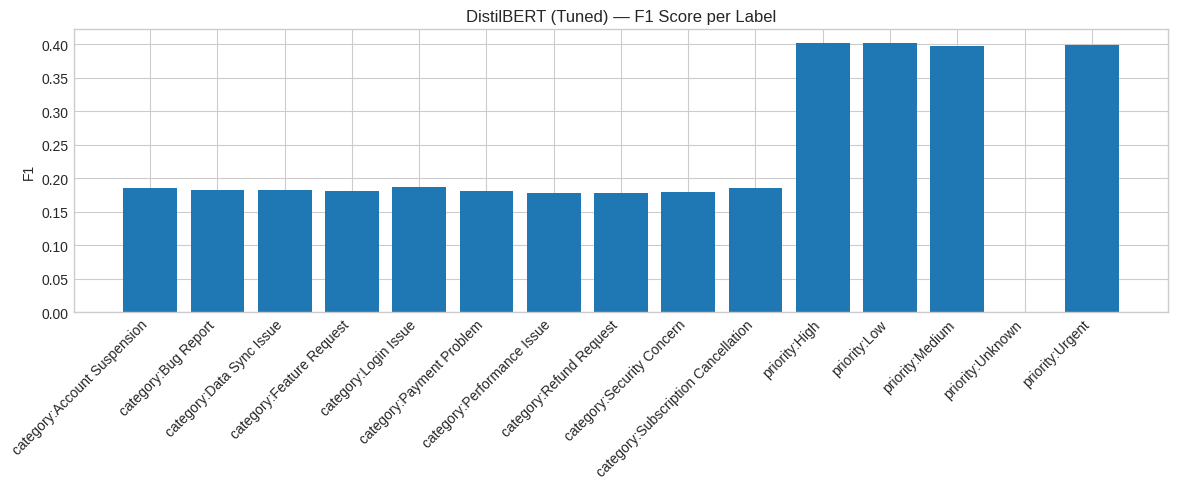

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# --- Per-label performance report (DistilBERT tuned thresholds) ---
print("Per-label classification report (DistilBERT, tuned thresholds):")
print(
    classification_report(
        Y_test,
        bert_test_preds_tuned,
        target_names=mlb.classes_,
        zero_division=0,
    )
)

# --- Plot: F1 score per label (DistilBERT tuned thresholds) ---
f1_scores = per_label_df.sort_values(by="label")["f1"].to_numpy()
labels_sorted = per_label_df.sort_values(by="label")["label"].to_list()

plt.figure(figsize=(12, 5))
plt.bar(labels_sorted, f1_scores)
plt.xticks(rotation=45, ha="right")
plt.title("DistilBERT (Tuned) — F1 Score per Label")
plt.ylabel("F1")
plt.tight_layout()
plt.show()


Confusion matrices (DistilBERT tuned) for top supported labels:


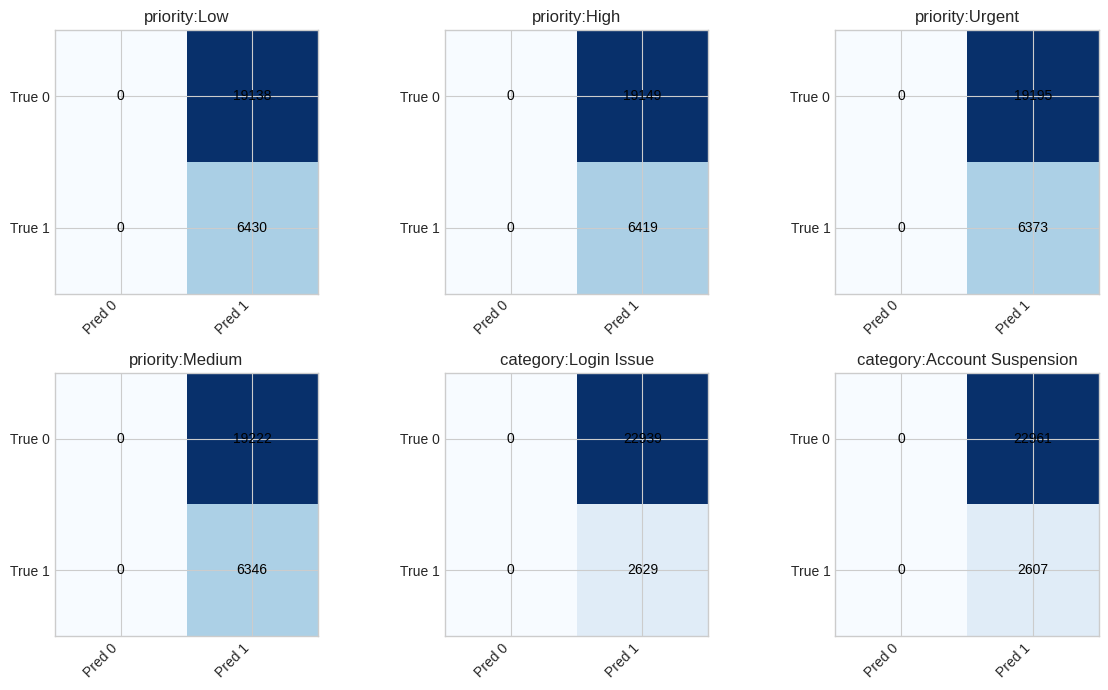

In [28]:
# --- Confusion matrix per label (2x2) for top-N supported labels ---
print("\nConfusion matrices (DistilBERT tuned) for top supported labels:")
N = 6
labels_by_support = per_label_df.sort_values(by="support", ascending=False).head(N)["label"].to_list()

# Precompute confusion components
from sklearn.metrics import confusion_matrix

y_true = np.asarray(Y_test)
y_pred = bert_test_preds_tuned

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for ax, lab in zip(axes, labels_by_support):
    k = list(mlb.classes_).index(lab)
    cm = confusion_matrix(y_true[:, k], y_pred[:, k], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(lab)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"], rotation=45, ha="right")
    ax.set_yticklabels(["True 0", "True 1"])

    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="black")

# Hide unused axes if any
for i in range(len(labels_by_support), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


---

## Final Demo: Prediction Pipeline
The following function, predict_ticket_demo, serves as complete end-to-end inference pipeline. It takes a raw customer support ticket and passes it through both traditional machine learning baselines and fine-tuned deep learning model to compare their predictions side-by-side.

In [29]:
# --- Final demo: single-ticket prediction function ---
import numpy as np
import pandas as pd
import torch


def predict_ticket_demo(text: str, top_k: int = 6):
    """Demo prediction for one ticket across baseline + DistilBERT.

    Returns a dict with:
    - cleaned_text
    - ovr_labels
    - chain_labels
    - bert_top_probs (top-k labels by probability)
    - bert_pred_labels_tuned (using tuned per-label thresholds from validation)
    """

    cleaned = clean_ticket_text(text)

    # --- Baselines (TF-IDF) ---
    x_tfidf = tfidf.transform([cleaned])
    ovr_pred = ovr_model.predict(x_tfidf)[0]
    chain_pred = chain_model.predict(x_tfidf)[0]

    ovr_labels = [mlb.classes_[i] for i, v in enumerate(ovr_pred) if v == 1]
    chain_labels = [mlb.classes_[i] for i, v in enumerate(chain_pred) if v == 1]

    # --- DistilBERT ---
    inputs = tokenizer(
        cleaned,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt",
    )

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"].to(model.device),
            attention_mask=inputs["attention_mask"].to(model.device),
        )
        probs = torch.sigmoid(outputs.logits).cpu().numpy().flatten()

    # tuned thresholds (computed in the evaluation cell)
    pred_tuned = (probs >= thresholds).astype(int)
    bert_pred_labels_tuned = [mlb.classes_[i] for i, v in enumerate(pred_tuned) if v == 1]

    # top-k
    top_idx = np.argsort(-probs)[:top_k]
    bert_top_probs = [(mlb.classes_[i], float(probs[i])) for i in top_idx]

    return {
        "cleaned_text": cleaned,
        "ovr_labels": ovr_labels,
        "chain_labels": chain_labels,
        "bert_pred_labels_tuned": bert_pred_labels_tuned,
        "bert_top_probs": bert_top_probs,
    }


# Example usage
example_text = "My account was charged twice for the same invoice and I need a refund ASAP."
demo_out = predict_ticket_demo(example_text, top_k=6)

print("=== Demo Prediction ===")
print("Text:", example_text)
print("Cleaned:", demo_out["cleaned_text"])
print("OvR:", demo_out["ovr_labels"])
print("Classifier Chain:", demo_out["chain_labels"])
print("DistilBERT (tuned labels):", demo_out["bert_pred_labels_tuned"])
print("DistilBERT (top probs):")
for lab, p in demo_out["bert_top_probs"]:
    print(f"  {lab}: {p:.3f}")


=== Demo Prediction ===
Text: My account was charged twice for the same invoice and I need a refund ASAP.
Cleaned: my account was charged twice for the same invoice and i need a refund asap
OvR: ['category:Data Sync Issue', 'category:Feature Request', 'category:Payment Problem', 'category:Performance Issue', 'category:Security Concern', 'category:Subscription Cancellation', 'priority:High']
Classifier Chain: ['category:Bug Report', 'priority:High']
DistilBERT (tuned labels): ['category:Account Suspension', 'category:Bug Report', 'category:Data Sync Issue', 'category:Feature Request', 'category:Login Issue', 'category:Payment Problem', 'category:Performance Issue', 'category:Refund Request', 'category:Security Concern', 'category:Subscription Cancellation', 'priority:High', 'priority:Low', 'priority:Medium', 'priority:Urgent']
DistilBERT (top probs):
  priority:Urgent: 0.253
  priority:High: 0.251
  priority:Medium: 0.246
  priority:Low: 0.245
  category:Feature Request: 0.103
  categor

# Conclusion

## Prototype Summary
This project successfully developed a reproducible multi-label classification pipeline for customer support ticket triage. A leakage-aware experimental framework was implemented to ensure fair comparison between traditional machine learning approaches (One-vs-Rest and Classifier Chains using TF-IDF) and a deep learning model (DistilBERT) based on contextual embeddings.

## Key Findings
1. **Importance of Evaluation Metrics:**  
   Micro-F1 provided an overall performance measure, while Macro-F1 revealed the models’ effectiveness on minority and less frequent labels. This highlights the importance of using multiple evaluation metrics in multi-label classification tasks.

2. **Contextual Understanding vs. Sparse Representation:**  
   TF-IDF-based models demonstrated strong baseline performance with fast training times and interpretability. However, DistilBERT significantly improved the model’s ability to capture contextual meaning in customer queries, leading to better performance on complex and ambiguous cases.

3. **Handling Multi-Label Characteristics:**  
   The use of Binary Cross-Entropy (BCE) loss enabled effective learning of non-mutually exclusive labels, which is essential for real-world customer support scenarios where multiple issues may coexist.

## Limitations
- Class imbalance negatively impacts Macro-F1, particularly for rare labels  
- A fixed probability threshold (0.5) may not be optimal for all labels  
- Limited hyperparameter tuning due to computational constraints  

## Future Work
To transition this prototype into a production-ready system, the following improvements are recommended:
- Perform extensive hyperparameter optimization (e.g., increasing Optuna `n_trials` using cloud resources)  
- Apply per-label threshold tuning based on validation data to improve Macro-F1  
- Incorporate model monitoring and slice-based evaluation (e.g., across different product categories) to detect potential bias  
- Explore more advanced transformer architectures such as BERT or RoBERTa  

## Deployment Readiness
The pipeline supports artifact versioning, including trained model weights, tokenizer, and label mappings (`mlb.classes_`). This ensures reproducibility and enables seamless integration into a production environment, such as deployment via FastAPI or containerized services.